# nb03_opx_baseline_models (v10 Phase C)

Loads and visualizes the Phase C opx training results produced by `scripts/v10_phase_c_opx_driver.py` + `scripts/v10_phase_c_opx_runner.py`. 96 Optuna studies (8 models x 2 targets x 2 tracks x 3 feature sets), zero failures.


In [1]:
import os, sys
from pathlib import Path
ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from config import RESULTS
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 50)


## Base model results (96 rows)


In [2]:
df_bases = pd.read_csv(RESULTS / 'opx_per_cell_results.csv')
print(f'n_rows={len(df_bases)}')
df_bases.round(3)


n_rows=96


,model,target,track,feature_set,test_rmse,test_r2,cv_rmse
0,RF,T_C,opx_only,raw,158.203,0.190,141.213
1,ERT,T_C,opx_only,raw,163.120,0.138,139.512
2,XGB,T_C,opx_only,raw,150.564,0.266,136.762
3,GB,T_C,opx_only,raw,158.284,0.189,141.224
4,CatBoost,T_C,opx_only,raw,156.709,0.205,133.466
...,...,...,...,...,...,...,...
91,GB,P_kbar,opx_liq,pwlr,5.049,0.726,5.065
92,CatBoost,P_kbar,opx_liq,pwlr,5.231,0.706,5.141
93,LightGBM,P_kbar,opx_liq,pwlr,5.395,0.687,5.212
94,ElasticNet,P_kbar,opx_liq,pwlr,6.638,0.526,6.060


## Ensemble results (36 rows: ridge / two_level / greedy)


In [3]:
df_ens = pd.read_csv(RESULTS / 'opx_ensemble_results.csv')
df_ens.round(3)


,method,target,track,feature_set,test_rmse
0,ridge,T_C,opx_only,raw,154.254
1,two_level,T_C,opx_only,raw,151.213
2,greedy,T_C,opx_only,raw,152.701
3,ridge,T_C,opx_only,alr,149.577
4,two_level,T_C,opx_only,alr,159.862
5,greedy,T_C,opx_only,alr,152.942
6,ridge,T_C,opx_only,pwlr,154.526
7,two_level,T_C,opx_only,pwlr,155.073
8,greedy,T_C,opx_only,pwlr,154.480
9,ridge,T_C,opx_liq,raw,78.156


## Best base per (target, track)


In [4]:
idx = df_bases.groupby(['target', 'track'])['test_rmse'].idxmin()
best_per_cell = df_bases.loc[idx].reset_index(drop=True)
best_per_cell[['target','track','model','feature_set','test_rmse','test_r2']].round(3)


,target,track,model,feature_set,test_rmse,test_r2
0,P_kbar,opx_liq,MLP,raw,3.816,0.843
1,P_kbar,opx_only,XGB,pwlr,10.202,0.464
2,T_C,opx_liq,ElasticNet,raw,77.062,0.691
3,T_C,opx_only,LightGBM,alr,147.982,0.291


## Best ensemble per (target, track)


In [5]:
idx = df_ens.groupby(['target', 'track'])['test_rmse'].idxmin()
best_ens = df_ens.loc[idx].reset_index(drop=True)
best_ens.round(3)


,method,target,track,feature_set,test_rmse
0,greedy,P_kbar,opx_liq,raw,3.825
1,ridge,P_kbar,opx_only,pwlr,10.178
2,greedy,T_C,opx_liq,raw,78.025
3,ridge,T_C,opx_only,alr,149.577


## Figure: per-model test RMSE heatmap
Rows = 8 models, columns = (target, track, feature_set). Color = RMSE, lower is better (darker).


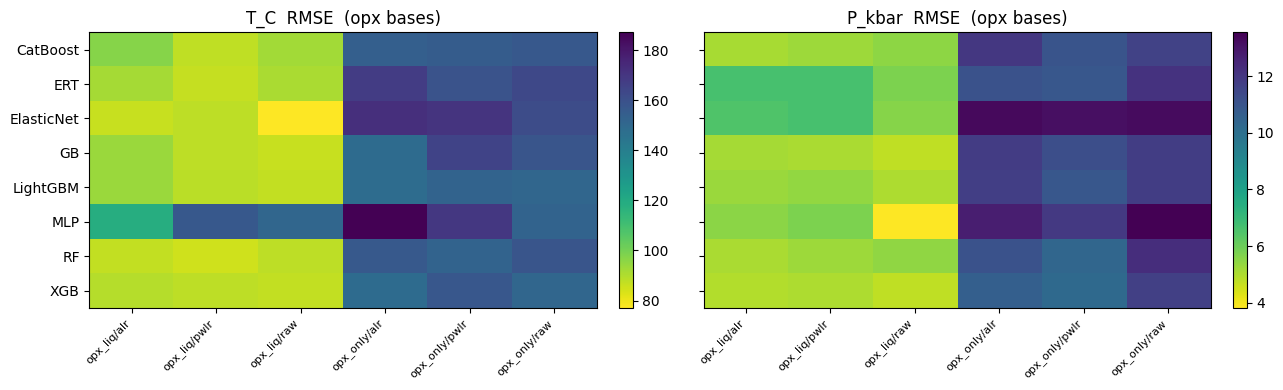

In [6]:
def rmse_heatmap(df, title):
    pv = df.pivot_table(index='model',
                        columns=['target','track','feature_set'],
                        values='test_rmse')
    fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
    for ax, tgt in zip(axes, ['T_C', 'P_kbar']):
        sub = pv[tgt]
        im = ax.imshow(sub.values, aspect='auto', cmap='viridis_r')
        ax.set_xticks(range(sub.shape[1]))
        ax.set_xticklabels([f'{t}/{f}' for t, f in sub.columns],
                           rotation=45, ha='right', fontsize=8)
        ax.set_yticks(range(sub.shape[0]))
        ax.set_yticklabels(sub.index)
        ax.set_title(f'{tgt}  RMSE  ({title})')
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    return fig

fig = rmse_heatmap(df_bases, 'opx bases')
plt.show()


## Figure: base vs ensemble RMSE per cell
Shows how much each ensemble beats the best base model.


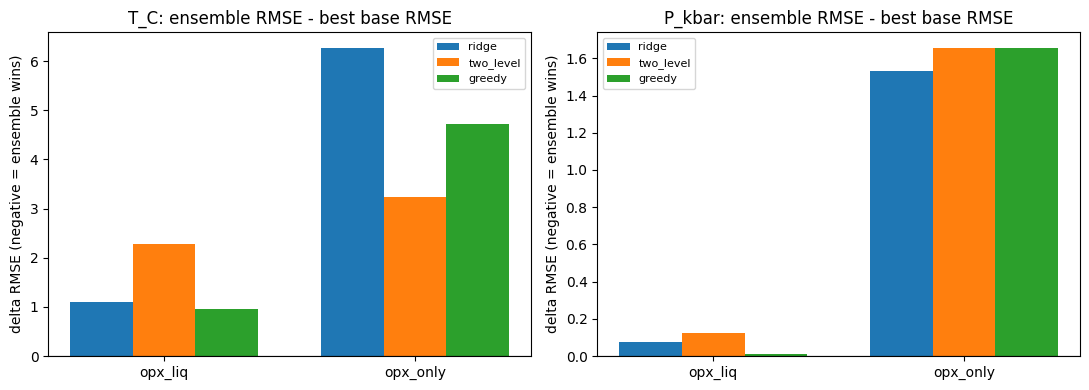

In [7]:
best_base = df_bases.loc[df_bases.groupby(['target','track'])['test_rmse']
                                  .idxmin(), ['target','track','test_rmse']]
best_base = best_base.rename(columns={'test_rmse': 'best_base_rmse'})
merged = df_ens.merge(best_base, on=['target', 'track'])
merged['delta'] = merged['test_rmse'] - merged['best_base_rmse']

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=False)
for ax, tgt in zip(axes, ['T_C', 'P_kbar']):
    sub = merged[merged['target'] == tgt]
    methods = sub['method'].unique()
    tracks  = sorted(sub['track'].unique())
    x = np.arange(len(tracks))
    w = 0.25
    for i, m in enumerate(methods):
        vals = [sub[(sub['method']==m) & (sub['track']==t)]['delta'].values[0]
                for t in tracks]
        ax.bar(x + i*w - w, vals, w, label=m)
    ax.axhline(0, color='k', lw=0.8)
    ax.set_xticks(x); ax.set_xticklabels(tracks)
    ax.set_title(f'{tgt}: ensemble RMSE - best base RMSE')
    ax.set_ylabel('delta RMSE (negative = ensemble wins)')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## Test protocol results (T01/T02/T11/T12)


In [8]:
from scripts.v10_test_protocol import summarize_tests
tests_df = summarize_tests(pipeline='opx')
print(f'n_test_rows={len(tests_df)}')
tests_df[['test_id','target','track','passed','value','threshold']].head(60)


n_test_rows=48


,test_id,target,track,passed,value,threshold
0,T01,P_kbar,opx_liq,True,0.678753,NaN
1,T01,P_kbar,opx_liq,True,0.138745,NaN
2,T01,P_kbar,opx_liq,True,0.217701,NaN
3,T01,P_kbar,opx_only,True,0.484132,NaN
4,T01,P_kbar,opx_only,True,0.499309,NaN
5,T01,P_kbar,opx_only,True,0.126019,NaN
6,T01,T_C,opx_liq,True,1.819835,NaN
7,T01,T_C,opx_liq,False,-2.448660,NaN
8,T01,T_C,opx_liq,False,-2.895044,NaN
9,T01,T_C,opx_only,True,7.638489,NaN


In [9]:
if not tests_df.empty:
    rate = tests_df.groupby('test_id')['passed'].agg(['sum', 'count'])
    rate['pass_rate'] = rate['sum'] / rate['count']
    print('Pass rate per test (across cells):')
    print(rate)


Pass rate per test (across cells):
         sum  count  pass_rate
test_id                       
T01       10     12   0.833333
T02        4     12   0.333333
T11        5     12   0.416667
T12        3     12   0.250000


## Summary

Phase C opx training is complete. Canonical models under `models/canonical/opx/`. Next phase: Phase G figures + manuscript compilation.
